# seq2seq 번역기

# 0. 라이브러리 import 및 setting

In [1]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)
print(torch.__version__)

cuda
2.7.1+cu126


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

In [3]:
DATA_DIR = os.path.join(os.getcwd(), "data")
print(DATA_DIR)

KOR_FILE_PATH = os.path.join(DATA_DIR, "korean-english-park.dev.ko")
ENG_FILE_PATH = os.path.join(DATA_DIR, "korean-english-park.dev.en")
print(KOR_FILE_PATH)

/home/minkyujeong/work/DeepDive/ch5_seq2seq/data
/home/minkyujeong/work/DeepDive/ch5_seq2seq/data/korean-english-park.dev.ko


In [4]:
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


In [5]:
plt.rcParams["font.family"] = "NanumBarunGothic"
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print(f"설정된 폰트: {plt.rcParams['font.family']}")

설정된 폰트: ['NanumBarunGothic']


# 1. 데이터 준비

In [6]:
with open(KOR_FILE_PATH, "r") as f:
    raw_kor = f.read().splitlines()

print("Data Size:", len(raw_kor))
print("Example:")
for sen in raw_kor[0:100][::20]: print(">>", sen) # 5개 문장 출력

Data Size: 1000
Example:
>> 세계 에서 가장 강력한 수퍼컴퓨터를 1년 동안이나 독점해 오던 정부의 연구학자들이 이 1억1천만 달러 짜리 경이로운 설비를 공개하며, 이것이 핵전쟁으로부터 세계를 구하는데 도움이 될지도 모른다고 말했다.
>> 무기 사찰관들의 복귀에 대하여 이라크 측의 한 관리가 "유익하고 효과적인" 논의였다고 말한 회합에서 유엔 무기 사찰단장이 이라크 대표단을 만났다.
>> 하드웨어를 구입하는 비용의 문제가 커다란 장애입니다.
>> 토의에 참가한 대부분의 사람들은 정부가 통신 내용을 도청할 수 있는 권리를 보유해야 할 필요성이 있는 합법적인 부분도 있다는 데에 동의를 한다.
>> 그는 눈에 띄지 않게 행동하는 것으로 알려져있다. 그는 영국 시사잡지 타임즈에서 “파티에 잘 참석하지 않는다”며 자신의 생활에 대한 날조된 이야기를 즐기고 있다.


In [7]:
with open(ENG_FILE_PATH, "r") as f:
    raw_eng = f.read().splitlines()

print("Data Size:", len(raw_eng))
print("Example:")
for sen in raw_eng[0:100][::20]: print(">>", sen)

Data Size: 1000
Example:
>> After keeping the world's most powerful supercomputer to themselves for a year, government researchers showed off the $110 million wonder and said it might help save the world from nuclear war.
>> The head of the U.N. weapons inspection team met with an Iraqi delegation in what a Baghdad official called "useful and fruitful" discussions on the return of weapons inspectors.
>> "The issue of it just being a hardware expense is a serious impediment.
>> Most of the people involved in the discussion agree that there is a legitimate area in which the government needs to retain the right to intercept communications.
>> He's been known to keep a low profile "You will never see me at a party," he told the Times of London and delights in concocting stories about his life.


In [8]:
raw_df = pd.DataFrame({'kor': raw_kor, "eng": raw_eng})
raw_df.head()

,kor,eng
0,세계 에서 가장 강력한 수퍼컴퓨터를 1년 동안이나 독점해 오던 정부의 연구학자들이 ...,After keeping the world's most powerful superc...
1,초당 12조3천억 번의 계산을 수행할수 있는 능력이 있는 로렌스 리버모아 국립 연구...,With the ability to perform 12.3 trillion calc...
2,미국은 1992년에 지하 핵실험을 중지시켰기 때문에 이러한 모의 실험은 한 치의 오...,Those simulations must be as precise as possib...
3,"에너지省의 핵 안보 차관인 존 고든 장군은 이 수퍼컴퓨터는 ""국가의 비축 핵무기를 ...","John Gordon, the Department of Energy's under ..."
4,ASCI White로 알려진 이 수퍼컴퓨터는 놀랄 정도로 엄청나게 많은 용도를 갖고...,The supercomputer known as ASCI White has a mi...


## 1.1 데이터 전처리

### 1.1.1 중복 제거

- 한국어, 영어 둘다 중복인 것은 제거 필요 (동일한 데이턱가 몇 번씩 들어가면 bias가 생길 수 있으므로)

In [9]:
print("한국어, 영어 둘다 중복인 데이터: ", raw_df.duplicated(subset=['kor', 'eng'], keep=False).sum())

한국어, 영어 둘다 중복인 데이터:  0


- 영어만 중복인 데이터  
&rarr; 영어 표현을 생성할 때 다양한 한국어 문장의 의미를 담을 수 있으므로, 각 케이스의 중복 건수와 문장을 보고 결정

In [10]:
raw_df[raw_df.duplicated(subset=['eng'], keep=False)][:4]

,kor,eng
130,한편 무아메르 굴러 이스탄불 주지사는 이번 폭발사건에 대해 “명백한 테러 행위”라며...,Istanbul Gov. Muammer Guler called the blasts ...
289,무안메르 굴러 이스탄불 주지사는 이번 폭발사건을 테러로 규정하고 “2개의 폭파장치가...,Istanbul Gov. Muammer Guler called the blasts ...
786,Bush to ask for additional $50bn regard to Kat...,"As water is pumped out of New Orleans, the dim..."
791,허리케인 카트리나가 뉴올리언스 지방을 강타한지 9일 만에 물이 점차 빠져나감에따라 ...,"As water is pumped out of New Orleans, the dim..."


In [11]:
print("영어만 중복인 데이터: ", raw_df.duplicated(subset=['eng'], keep=False).sum())

영어만 중복인 데이터:  38


In [12]:
# eng 컬럼의 빈도수를 계산하여 데이터프레임으로 변환
eng_counts = raw_df['eng'].value_counts().reset_index()
eng_counts.columns = ['eng', 'count']

# 그 중 중복된 것(2번 이상 등장)만 필터링
duplicate_counts = eng_counts[eng_counts['count'] > 1]

print(duplicate_counts)

                                                  eng  count
0   National Institute for International Education...      2
1   A neighbor says the murder of Hudson's mother ...      2
2              the storm linked to at least 4 deaths.      2
3   Weathermen forecast up to 300mm more rainfall ...      2
4   “GM's financing arm, GMAC, has been declared a...      2
5   The hail of Hezbollah rockets came after Israe...      2
6   U.S. government prosecutors are against bail b...      2
7   “There are 665 stations where customers will b...      2
8   Clarkson was working as a hostess at the House...      2
9   Brett Favre and the Jets becoming the first ti...      2
10  The talks could jumpstart a long-dormant peace...      2
11  The first jury deadlock tended to with the maj...      2
12  Scores of bullet-riddled bodies have been foun...      2
13  President Jalal Talabani called an emergency s...      2
14  As water is pumped out of New Orleans, the dim...      2
15  Istanbul Gov. Muamme

&rarr; 중복되더라도 2번씩만 중복되므로 삭제하지 않았음

- 한국어만 중복인 데이터  
&rarr; 같은 한국어 문장이라도 다양한 영어 문장으로 표현할 수 있으므로, 각 케이스의 중복 건수와 문장을 보고 결정

In [13]:
print("한국어만 중복인 데이터: ", raw_df.duplicated(subset=['kor'], keep=False).sum())

한국어만 중복인 데이터:  3


In [14]:
raw_df[raw_df.duplicated(subset=['kor'], keep=False)]

,kor,eng
927,영한사전 약어표 / 한영사전 약어표,Brett Favre and the Jets becoming the first ti...
962,영한사전 약어표 / 한영사전 약어표,“There are 665 stations where customers will b...
987,영한사전 약어표 / 한영사전 약어표,The talks could jumpstart a long-dormant peace...


&rarr; 한국어 문장 내용이랑 영어 문장이 대응되지 않으므로 위 3건에 대해서는 제외 결정

In [15]:
# 중복된 3건의 인덱스 추출
target_indices = raw_df[raw_df.duplicated(subset=['kor'], keep=False)].index

# 해당 인덱스만 제거
raw_df = raw_df.drop(target_indices)
len(raw_df)

997

#### 결측치 확인

In [16]:
print(raw_df.isnull().sum())

kor    0
eng    0
dtype: int64


### 1.1.2. 데이터 정제

In [17]:
# 한국어 정제 함수
def preprocess_kor_sentence(sentence):   
    
    # 1. 양끝 공백 제거
    sentence = sentence.strip()
    
    # 2. 연속된 공백을 하나로 통일 (스페이스, 탭 등)
    sentence = re.sub(r'\s+', ' ', sentence)
    
    # 3. 연속된 개행문자(\n) 정제
    # 문장 구분을 위해 \n은 살려두되, 2개 이상 연속되면 1개로 줄임
    sentence = re.sub(r'\n+', '\n', sentence)
    
    # 4. 반복되는 자음/모음 정제 (예: ㅋㅋㅋㅋ -> ㅋㅋ)    
    sentence = re.sub(r'([ㄱ-ㅎㅏ-ㅣ])\1+', r'\1\1', sentence)
    
    # 5. 반복되는 특수문자 정제 (예: .... -> ..)
    sentence = re.sub(r'([\.\!\?])\1+', r'\1\1', sentence)

    return sentence

In [ ]:
# # 영어 정제 함수
# def preprocess_eng_sentence(sentence):
#     sentence = sentence.lower().strip() # 소문자로 만들고 양쪽 공백 제거
#     sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
#     sentence = re.sub(r'[" "]+', " ", sentence)
#     sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence) # +: &&& -> " " / + 없으면: &&& -> " "" "" "

#     sentence = sentence.strip()

#     return sentence

In [19]:
from nltk.corpus import stopwords

In [20]:
stop_words = set(stopwords.words('english'))

def preprocess_eng_sentence(sentence, remove_stopwords=False):
    sentence = sentence.lower().strip() # 소문자로 만들고 양쪽 공백 제거
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence) # +: &&& -> " " / + 없으면: &&& -> " "" "" "

    sentence = sentence.strip()
    # 불용어 제거 (Text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stop_words and len(word) > 1)
    # 불용어 미제거 (Summary)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

In [21]:
raw_df['kor'] = raw_df['kor'].apply(preprocess_kor_sentence)
raw_df['eng'] = raw_df['eng'].apply(preprocess_eng_sentence, remove_stopwords=True)

In [22]:
# eng sentence 단어 개수 확인
eng_count = []
for eng_sent in raw_df['eng']:
    eng_count.append(len(eng_sent.split()))

eng_count = np.array(eng_count)
print(np.max(eng_count))
print(np.mean(eng_count))
print(np.median(eng_count))

44
12.898696088264794
12.0


&rarr; 평균적으로 24개의 단어를 갖고 있어서 v1 파일에서는 불용어 제거는 하지 않았으나(Ex_05_seq2seq_v0.9.ipynb 참조),  
&rarr; 번역 결과 의미없지만 자주 등장하는 단어들이 나와서 불용어를 제거하였음

#### 중복 여부 재확인

In [23]:
print("한국어, 영어 둘다 중복인 데이터: ", raw_df.duplicated(subset=['kor', 'eng'], keep=False).sum())
print("영어만 중복인 데이터: ", raw_df.duplicated(subset=['eng'], keep=False).sum())
print("한국어만 중복인 데이터: ", raw_df.duplicated(subset=['kor'], keep=False).sum())

한국어, 영어 둘다 중복인 데이터:  0
영어만 중복인 데이터:  32
한국어만 중복인 데이터:  0


In [24]:
# eng 컬럼의 빈도수를 계산하여 데이터프레임으로 변환
eng_counts = raw_df['eng'].value_counts().reset_index()
eng_counts.columns = ['eng', 'count']

# 그 중 중복된 것(2번 이상 등장)만 필터링
duplicate_counts = eng_counts[eng_counts['count'] > 1]

print(duplicate_counts)

                                                  eng  count
0   clarkson working hostess house blues met spect...      2
1   embattled world bank president paul wolfowitz ...      2
2   hail hezbollah rockets came israeli troops rai...      2
3   government prosecutors bail set south korean l...      2
4   weathermen forecast mm rainfall southwestern p...      2
5   first jury deadlock tended majority favoring c...      2
6   water pumped new orleans diminishing flood rev...      2
7   scores bullet riddled bodies found baghdad blo...      2
8   president jalal talabani called emergency summ...      2
9   national institute international education dev...      2
10                          storm linked least deaths      2
11  gm financing arm gmac declared bank holding co...      2
12  neighbor says murder hudson mother brother chi...      2
13  istanbul gov muammer guler called blasts act t...      2
14            big time blood money weekend box office      2
15  move criticized exce

#### 결측치 확인

In [25]:
print(raw_df.isnull().sum())

kor    0
eng    0
dtype: int64


#### 파일로 저장

In [27]:
kor_path = os.path.join(DATA_DIR, "kor_corpus_new.txt")
eng_path = os.path.join(DATA_DIR, "eng_corpus_new.txt")
raw_df["kor"].to_csv(kor_path, index=False, header=False, sep="\n", encoding="utf-8")
raw_df["eng"].to_csv(eng_path, index=False, header=False, sep="\n", encoding="utf-8")

print("파일 저장 완료: kor_corpus_new.txt, eng_corpus_new.txt")

파일 저장 완료: kor_corpus_new.txt, eng_corpus_new.txt


### 1.2. 토크나이징

In [28]:
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

enc_path = os.path.join(DATA_DIR, "encoder_kor_new_spm")
dec_path = os.path.join(DATA_DIR, "decoder_eng_new_spm")

In [29]:
# 한국어 인코더 토크나이징
VOCAB_SIZE_KOR = 4500 # 4968이하로 하라고 에러남

spm.SentencePieceTrainer.train(
    input = kor_path,
    model_prefix = enc_path,
    vocab_size = VOCAB_SIZE_KOR,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/minkyujeong/work/DeepDive/ch5_seq2seq/data/kor_corpus_new.txt
  input_format: 
  model_prefix: /home/minkyujeong/work/DeepDive/ch5_seq2seq/data/encoder_kor_new_spm
  model_type: UNIGRAM
  vocab_size: 4500
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  un

In [30]:
# 영어 디코더 토크나이징
VOCAB_SIZE_ENG = 2800 # 3345 -> 2967 이하로 하라고 에러남

spm.SentencePieceTrainer.train(
    input = eng_path,
    model_prefix = dec_path,
    vocab_size = VOCAB_SIZE_ENG,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(77) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/minkyujeong/work/DeepDive/ch5_seq2seq/data/eng_corpus_new.txt
  input_format: 
  model_prefix: /home/minkyujeong/work/DeepDive/ch5_seq2seq/data/decoder_eng_new_spm
  model_type: UNIGRAM
  vocab_size: 2800
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  un

In [35]:
enc_tokenizer = spm.SentencePieceProcessor()
enc_tokenizer.load(os.path.join(DATA_DIR, "encoder_kor_new_spm.model"))

dec_tokenizer = spm.SentencePieceProcessor()
dec_tokenizer.load(os.path.join(DATA_DIR, "decoder_eng_new_spm.model"))

True

In [36]:
kor_sample = raw_df['kor'][100]
eng_sample = raw_df['eng'][100]
print(kor_sample)
print(eng_sample)

미국 전력회사들처럼 중국의 거대 기업들도 재생에너지에 더 많은 투자를 하고 있다.
like american counterparts chinese tycoons increasingly directing investment renewable power


In [37]:
enc_tok = enc_tokenizer.encode(kor_sample)
enc_tok = [enc_tokenizer.bos_id()] + enc_tok + [enc_tokenizer.eos_id()]
enc_tok

[1,
 51,
 1480,
 3310,
 610,
 481,
 75,
 8,
 1040,
 2755,
 26,
 4,
 2963,
 2381,
 14,
 96,
 135,
 11,
 506,
 12,
 4,
 41,
 27,
 5,
 2]

In [38]:
enc_decode = enc_tokenizer.decode(enc_tok)
enc_decode

'미국 전력회사들처럼 중국의 거대 기업들도 재생에너지에 더 많은 투자를 하고 있다.'

##  1.3. 학습 데이터로 변환

### 1.3.1. MAX_TOKEN_LEN 결정

In [39]:
enc_tokenizer = spm.SentencePieceProcessor()
enc_tokenizer.load(os.path.join(DATA_DIR, "encoder_kor_new_spm.model"))

dec_tokenizer = spm.SentencePieceProcessor()
dec_tokenizer.load(os.path.join(DATA_DIR, "decoder_eng_new_spm.model"))

True

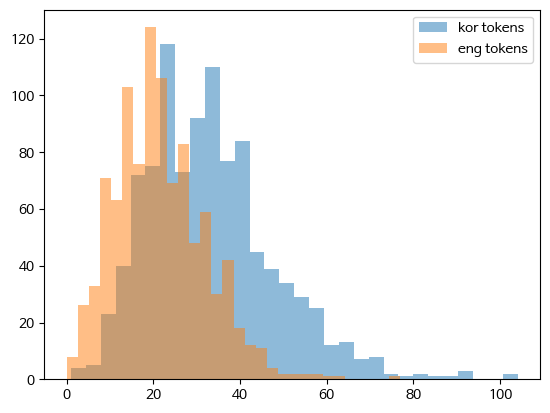

kor 토큰 최대: 104
eng 토큰 최대: 77


In [40]:
kor_token_lens = [len(enc_tokenizer.encode_as_ids(kor_sentence)) for kor_sentence in raw_df['kor']]
eng_token_lens = [len(dec_tokenizer.encode_as_ids(eng_sentence)) for eng_sentence in raw_df['eng']]

plt.hist(kor_token_lens, bins=30, alpha=0.5, label='kor tokens')
plt.hist(eng_token_lens, bins=30, alpha=0.5, label='eng tokens')
plt.legend()
plt.show()

print(f"kor 토큰 최대: {max(kor_token_lens)}")
print(f"eng 토큰 최대: {max(eng_token_lens)}")

In [41]:
# BOS, EOS 토큰 고려하면 최소 80이상 지정 필요
# inference 단계에서 더 긴 글이 들어올 수 있으므로 128로 지정하고
# 편의상 인코더, 디코더 공용으로 사용
MAX_TOKEN_LEN = 128

### 1.3.2. Dataset 및 DataLoader 생성

In [42]:
class TransDataset(Dataset):

    def __init__(self, data, enc_tokenizer, dec_tokenizer, max_len):
        self.data = data
        self.enc_tokenizer = enc_tokenizer
        self.dec_tokenizer = dec_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2        
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['kor']
        tgt_text = self.data.iloc[idx]['eng']

        src_ids = self.enc_tokenizer.encode(src_text)
        tgt_ids = self.dec_tokenizer.encode(tgt_text)

        src_ids = src_ids[:self.max_len]

        # decoder의 입력에 bos, eos 토큰 추가, 단, 최대 길이 제한을 적용
        # tgt_input = [self.bos_id] + tgt_ids[:self.max_len-2] + [self.eos_id] 
        tgt_input = [self.bos_id] + tgt_ids[:self.max_len-1]
        tgt_label = tgt_ids[:self.max_len-1] + [self.eos_id]


        # 길이가 짧은 경우 PAD 토큰 추가
        src_ids = src_ids + [self.pad_id]*(self.max_len - len(src_ids))
        tgt_input = tgt_input + [self.pad_id]*(self.max_len - len(tgt_input))
        tgt_label = tgt_label + [self.pad_id]*(self.max_len - len(tgt_label))

        return torch.tensor(src_ids), torch.tensor(tgt_input), torch.tensor(tgt_label)

In [43]:
BATCH_SIZE = 16

train_dataset = TransDataset(raw_df, enc_tokenizer, dec_tokenizer, MAX_TOKEN_LEN)
train_loader = DataLoader(dataset = train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [44]:
for src, tgt_input, tgt_label in train_loader:
    print(src.shape, tgt_input.shape, tgt_label.shape)
    break

torch.Size([16, 128]) torch.Size([16, 128]) torch.Size([16, 128])


# 2. 모델 정의

In [45]:
# Bahdanau Attention 사용
class BahdanauAttn(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.w_enc = nn.Linear(hidden_dim, hidden_dim)
        self.w_dec = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1)

    def forward(self, single_hidden, enc_out):
        # single_hidden: (batch, h_dim) # 한 시점(토큰)의 hidden_state
        # enc_out: (batch, seq_len, h_dim) # batch_first로 받아온 enc_out (encoder의 모든 시점 hidden_state)

        src_seq_len = enc_out.shape[1]
        
        # (batch, h_dim) -> (batch, src_seq_len, h_dim) 
        # (1, src_seq_len, 1)에서 1: batch, 1: h_dim 그대로 유지됨
        single_hidden = single_hidden.unsqueeze(1).repeat(1, src_seq_len, 1)                 

        energy = torch.tanh(self.w_enc(enc_out) + self.w_dec(single_hidden)) # (batch, src_seq_len, hidden_dim)
        # (batch, src_seq_len, hidden_dim) -> (batch, src_seq_len, 1) -> (batch, src_seq_len)
        attn_weights = self.v(energy).squeeze(2) 

        return F.softmax(attn_weights, dim=1) # src_seq_len (전체 time, 토큰)에 대한 softmax 


In [46]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, h_dim):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.h_dim = h_dim

        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.GRU(emb_dim, h_dim, batch_first=True)

    def forward(self, src):
        # x: (batch, seq_len)
        emb_vec = self.embedding(src) # (batch, seq_len, emb_dim)
        # print("emb_shape:     ", emb_vec.shape)
        out, h = self.rnn(emb_vec) 
        # out : (batch, seq_len, h_dim*direction)  # batch_first 
        # h, c: seq_len 마지막 요소(layer*direction, batch, h_dim)
        return out, h

In [47]:
enc = Encoder(10000, 256, 512)
out, h = enc(torch.randint(0, 10000, (10, 30)))
print(out.shape, h.shape)
print((out[0, -1] == h[0, 0]).all())

torch.Size([10, 30, 512]) torch.Size([1, 10, 512])
tensor(True)


In [48]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, h_dim, attn):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.h_dim = h_dim

        self.attn = attn # (batch, src_seq_len) 가져옴
        self.embedding = nn.Embedding(vocab_size, emb_dim) # (batch, seq_len) -> (batch, seq_len, imb_dim)
        self.rnn = nn.GRU(emb_dim, h_dim, batch_first=True)
        # 출력층에는 hidden과 attn values가 결합되어 입력
        self.fc_out = nn.Linear(h_dim + h_dim, vocab_size) # attn(enc_out, dec_h_t-1), dec_h_t을 concat
    
    
    def forward(self, tgt_input, hidden, enc_out):
        # 하나의 토큰(time) 단위 계산하는 구조를 상정하고 짠 코드임 -> look-ahead mask 처리 안 해도 됨
        # tgt_input: (batch, ) -> [64] # (batch, 1) 아님 주의 # 해당 시점의 토큰을 batch 개수 만큼 처리 
        # hidden: (batch, h_dim) (n_layer*direction, batch, h_dim) # 마지막 시점(토큰)의 hidden state
        # hidden[-1]: (batch, h_dim) # 마지막 layer(time, 토큰 아님)의 hidden_state
        # enc_out (batch_first): (batch, seq_len, h_dim) # 이름은 out이지만 모든 time(토큰)의 hidden_state임
        
        tgt_input = tgt_input.unsqueeze(1) # (batch,) -> (batch, 1)        
        # tgt input 임베딩화
        emb = self.embedding(tgt_input) # (batch, 1, emb_dim)
        # print(emb.shape)
        # print("hidden   ", hidden.shape)
        # print("enc_out  ", enc_out.shape)

        # attn value 계산 (enc_out, 이전 스텝 hidden 이용)        
        # decoder의 이전 hidden state인 s_{t-1}, enc_out인 H가 입력
        # (batch, h_dim), (batch, src_len, h_dim) 넣고 연산해서 (batch, src_seq_len) 가져옴
        attn_weights = self.attn(hidden[-1], enc_out) # (batch, src_seq_len)        

        # H(enc_out, 인코더 전체 hidden_state)에 가중치를 부여해 attn values (context vector)계산
        attn_weights = attn_weights.unsqueeze(1) # (batch, src_seq_len) -> (batch, 1, src_seq_len)
        # (batch, 1, src_len), (batch, src_len, h_dim) 
        # -> (batch, 1, h_dim) 현재 시점(t)의 디코더 hidden_state에 더해줄 수 있게 됨
        attn_values = torch.bmm(attn_weights, enc_out) # (batch, 1, h_dim)
        attn_values = attn_values.permute(1, 0, 2) # (1, batch, h_dim) 왜냐하면 rnn의 h가 (1, batch, h_dim)으로 나오니까
        
        # 이전 시점(t-1)의 hidden을 같이 넣어줌 (한 시점,토큰씩 계산하니까)
        # print("dec input emb.....", emb.shape)
        # print("hidden emb.....", hidden.shape)
        out, cur_h = self.rnn(emb, hidden) # (batch, 1, emb_dim), (n_layer*direction, batch, h_dim) 
        # out: (batch, 1, h_dim) # batch_first 써서
        # cur_h: 현재 시점 hidden_state (n_layer*direction, batch, h_dim)        

        # 한 시점(토큰) 단위로 돌리니까 현재 out이랑 현재 hidden은 동일하게 나와야 함
        # print("한 시점 비교:", out.squeeze(1) == cur_h[-1]) # [True, True, ...]

        # 출력층에서는 현재 hidden_state와 attn_values(context vector)를 결합하여 예측값 생성
        out = out.squeeze(1) # (batch, 1, h_dim) -> (batch, h_dim)
        attn_values = attn_values.squeeze(0) # (batch, h_dim)
        pred = self.fc_out(torch.cat([out, attn_values], dim=1)) # (batch, vocab_size)

        # (batch, vocab_size), (n_layer*direction, batch, h_dim), (batch, src_seq_len)
        return pred, cur_h, attn_weights.squeeze(1)

In [49]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt=None, max_len=30, bos_id=1, eos_id=2):
        # 학습 모드에서는 tgt_seq_len 사용, 추론 모드에서는 max_len까지 동적 생성
        # batch_size = src.shape[1] 
        
        batch_size = src.shape[0]
        # tgt_vocab_size = self.decoder.vocab_size
        tgt_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 list 사용 (길이가 조절이 tesnor보다 유연하다는 의미)
        outputs = []
        # 시각화를 위해 attention 저장
        attns = []
        # 인코더를 통해 context 생성
        enc_outs, enc_h = self.encoder(src) # (batch, src_len, h_dim), (n_layers*direction, batch, h_dim)
        

        dec_h = enc_h # 헷갈려서 변수 구분, 디코더 맨 첫 셀의 h는 enc_h이 들어가야 해서 넘겨줌
        if tgt is not None:                      
            for t in range(tgt.shape[1]): # dec_seq_len 만큼 반복해야 함. 한 토큰(시점) 단위로 돌리니까
                # bos부터 집어 넣음
                dec_input = tgt[:, t] # (batch,) [64] -> unsqueeze(1) 필요, decoder에서 수행
                # print("input_shape   ", dec_input.shape)
                dec_out, dec_h, attn = self.decoder(dec_input, dec_h, enc_outs) # 첫번째 입력 dec_h는 enc_h
                outputs.append(dec_out.unsqueeze(1)) # (batch, vocab_size) -> # (batch, 1, vocab_size)
                attns.append(attn.unsqueeze(1)) # (batch, src_seq_len) -> (batch, 1, src_seq_len)                

        else:
            # inference에서는 tgt_label이 없기 때문에 sos_token을 생성
            dec_input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device) # [bos_id, bos_id, ... ]
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device) # [False, False, ... ]

            for t in range(max_len):
                dec_out, dec_h, attn = self.decoder(dec_input, dec_h, enc_outs) # 첫번째 입력 dec_h는 enc_h
                outputs.append(dec_out.unsqueeze(1)) # batch_first로 얻어서
                attns.append(attn.unsqueeze(0))
                top1 = dec_out.argmax(dim=1) # (batch, vocab_size) -> vocab 중 가장 높은 확률의 단어 선택
                dec_input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id) # 한 번이라도 True 나오면 finished 요소 전부 True로 할당
                if finished.all():
                    break
        
        # outputs = torch.cat(outputs, dim=0) # batch, tgt_len, out_dim
        # attns = torch.cat(attns, dim=0) # batch, tgt_len, out_dim
        
        outputs = torch.cat(outputs, dim=1) # (batch, 1, vocab_size) -> (batch, tgt_len, vocab_size)
        attns = torch.cat(attns, dim=1) # (batch, 1, src_seq_len) -> (batch, tgt_len, src_seq_len)        

        return outputs, attns

# 3. 모델 학습

In [50]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

enc_vocab_size = len(enc_tokenizer) # vocab_size
print(enc_vocab_size)
dec_vocab_size = len(dec_tokenizer)
print(dec_vocab_size)

emb_dim = 256
# h_dim = 512
h_dim = 256

4500
2800


In [51]:
encoder = Encoder(enc_vocab_size, emb_dim, h_dim).to(DEVICE)
attention = BahdanauAttn(h_dim).to(DEVICE)
decoder = Decoder(dec_vocab_size, emb_dim, h_dim, attention).to(DEVICE)
model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

In [52]:
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

In [53]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    # desc: 진행바 맨 앞에 붙을 제목
    # leave=True: 100% 되었을 때(1 에폭 완료 시) 결과 그대로 남김 (이전 에폭 결과 볼 수 있음)
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, tgt_input, tgt_label in progress_bar:
        # 모델의 입력 순서에 맞게 변환        
        # src = src.permute(1, 0).to(device)
        # trg_input = trg_input.permute(1, 0).to(device)
        # trg_label = trg_label.permute(1, 0).to(device)
        
        # (batch, seq_len) 으로 넣음 (batch_first 써서)
        src = src.to(DEVICE) 
        tgt_input = tgt_input.to(DEVICE)
        tgt_label = tgt_label.to(DEVICE)

        optimizer.zero_grad()

        outputs, _ = model(src, tgt_input)

        # (batch, tgt_seq_len, h_dim) -> (batch*tgt_len, h_dim)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        # print(tgt_label.shape)
        tgt_label = tgt_label.reshape(-1) # 1차원 정수 라벨 (batch*tgt_seq_len, ) 
        # print(tgt_label.shape)

        loss = criterion(outputs, tgt_label) # 한 시점(토큰)에 대해 batch 단위 loss 계산
        loss.backward()
        
        # gradient vector의 norm(크기)를 1로 제한해서 기울기 폭주 방지
        # 기울기 norm = 4 -> 전체 요소 x 0.25
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        # 진행 바의 맨 뒤(오른쪽)에 표시될 텍스트를 설정 
        # set_postfic('화면에 표시될 이름(문자열로 출력됨)' = 변수(출력할 값))
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader) # 배치 단위 loss 다 더했으니까 전체 배치 개수로 나눠줌

In [54]:
EPOCHS = 20
history = {'train_loss':[]}

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    # val_loss = val_step(model, train_loader, optimizer, criterion, epoch)
    history['train_loss'].append(train_loss)

    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 63/63 [00:07<00:00,  7.89it/s, loss=6.69]


Epoch 1/20, Train Loss: 7.0504


Epoch 2: 100%|██████████| 63/63 [00:06<00:00,  9.02it/s, loss=6.05]


Epoch 2/20, Train Loss: 6.3077


Epoch 3: 100%|██████████| 63/63 [00:06<00:00,  9.04it/s, loss=5.43]


...

Epoch 18/20, Train Loss: 0.0958


Epoch 19: 100%|██████████| 63/63 [00:06<00:00,  9.11it/s, loss=0.0903]


Epoch 19/20, Train Loss: 0.0785


Epoch 20: 100%|██████████| 63/63 [00:06<00:00,  9.15it/s, loss=0.0631]

Epoch 20/20, Train Loss: 0.0659


#### Learning curve

In [55]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(6, 4))

    # 1. Loss 그래프 (왼쪽)
    # plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    # plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training Loss')
    plt.xticks(epochs)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout() # 그래프 간 간격 자동 조절
    plt.show()

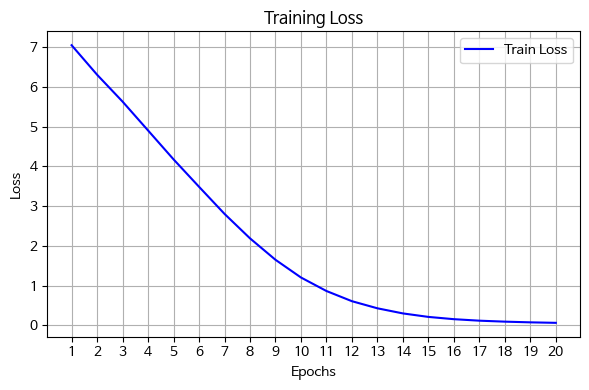

In [56]:
plot_history(history)

#### 모델 저장

In [57]:
min_loss = min(history['train_loss'])
min_loss_epoch = history['train_loss'].index(min_loss) + 1

print(min_loss)
print(min_loss_epoch)

model_name = os.path.join(os.getcwd(), f'models/new_model-epoch-{min_loss_epoch}-loss-{min_loss:.4f}-emb-{emb_dim}-h_dim-{h_dim}.pt')
print(model_name)

0.06591235302270405
20
/home/minkyujeong/work/DeepDive/ch5_seq2seq/models/new_model-epoch-20-loss-0.0659-emb-256-h_dim-256.pt


In [58]:
# 모델 저장
torch.save(model.state_dict(), model_name)

# 4. 결과 확인

In [59]:
def evaluate(sentence, model, enc_tokenizer, dec_tokenizer, max_len=30):
    model.eval()

    sentence = preprocess_kor_sentence(sentence)
    src_ids = enc_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len] # 최대 길이까지만 입력 (max_len이 더 커도 에러 안 남)
    src_ids = src_ids + [0]*(max_len - len(src_ids))    
    src_tensor = torch.tensor(src_ids).unsqueeze(0).to(DEVICE) # (batch: 1, src_seq_len)
        
    with torch.no_grad():
        # inference
        outs, attns = model(src_tensor, max_len=max_len) # (batch: 1, src_seq_len)
        # outs: (batch: 1, tgt_len: max_len, vocab_size)
        # attns: (batch: 1, tgt_len: max_len, src_seq_len)
    
    # vocab 중 가장 큰 단어
    # argmax(dim=2) -> (batch: 1, tgt_len: max_len)
    # squeeze(0) -> (tgt_len: max_len, ) # 예측 문장 길이만큼만 남음
    
    res = [dec_tokenizer.decode([token.item()]) for token in outs.argmax(dim=2).squeeze(0)]

    if "<end>" in res:
        res = res[:res.index("<end>")] # "<end>"값이 등장하는 index를 저장
    
    # attns: (batch: 1, tgt_len: max_len, src_seq_len) -> (tgt_len: max_len, src_seq_len)
    return res, sentence, attns.squeeze(0).cpu().numpy()
        

In [60]:
def plot_attn(attn, sentence, pred_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attn, cmap='viridis')

    fontdict = {'fontsize':11}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontdict=fontdict, rotation=45)

    ax.set_yticks(range(len(pred_sentence)))
    ax.set_yticklabels(pred_sentence, fontdict=fontdict)

    plt.show()

In [61]:
def translate(sentence, model, enc_tokenizer, dec_tokenizer, max_len=30):
    res, sentence, attn = evaluate(sentence, model, enc_tokenizer, dec_tokenizer, max_len)

    print("Input: %s"%(sentence))
    print("Predicted translation: {}".format(res))

    # Attention 크기 조정 (tgt_len, src_len)
    print(attn.shape)
    attn = attn[:len(res), :len(sentence.split())]

    plot_attn(attn, sentence.split(), res)

In [62]:
loaded_model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
checkpoint = torch.load(model_name, map_location=DEVICE)
loaded_model.load_state_dict(checkpoint)
loaded_model.eval() # 평가 모드로 변경
print("evaluation mode")

evaluation mode


In [63]:
example_sentence = [    
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

Input: 시민들은 도시 속에 산다.
Predicted translation: ['delegation', 's', 'suppo', 's', 'ed', 'remov', 'ed', 'month', 'personal', 'product', '']
(11, 30)


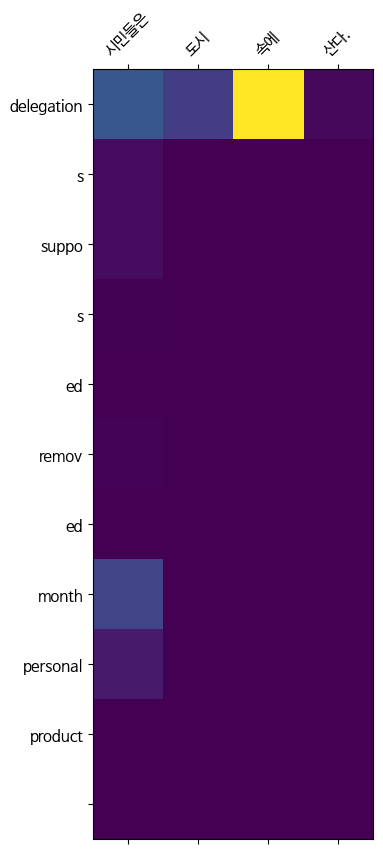

Input: 커피는 필요 없다.
Predicted translation: ['used', 'right', 'general', 'ly', 'work', 'prepa', 'id', '']
(8, 30)


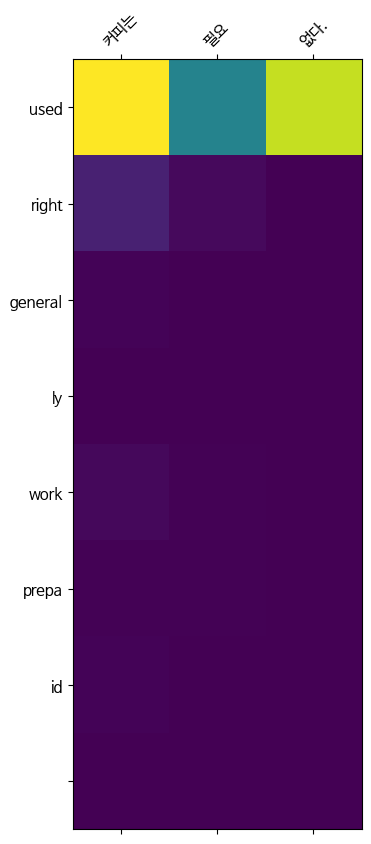

Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ['w', 'ould', 'wor', 'st', 'thing', 'career', '']
(7, 30)


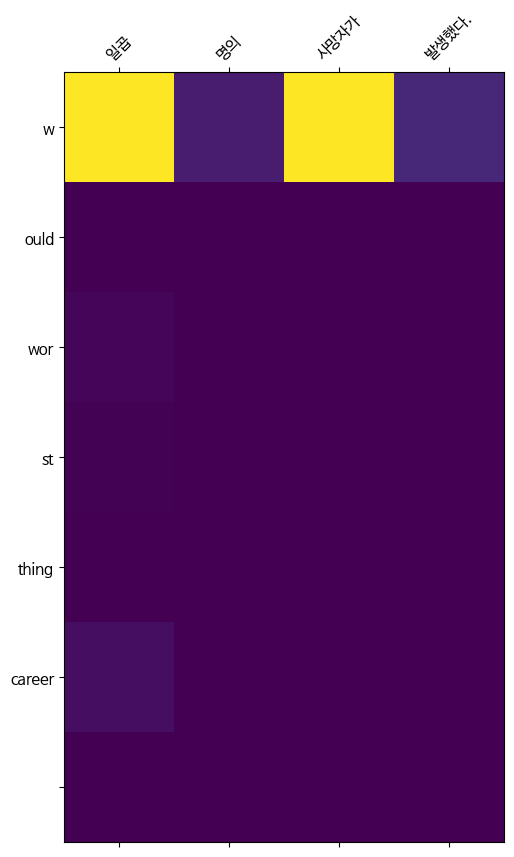

In [65]:
for sententence in example_sentence:
    translate(sententence, loaded_model, enc_tokenizer, dec_tokenizer, max_len=30)

&rarr; 번역 성능이 좋지 않은 것을 볼 수 있음

- 학습데이터에 있는 한국어 문장으로 테스트

In [66]:
train_example_sentence = raw_df['kor'][100:200][::20]
train_example_sentence

100        미국 전력회사들처럼 중국의 거대 기업들도 재생에너지에 더 많은 투자를 하고 있다.
120    깁슨은 “파일럿은 그가 연습 때 배웠던 것처럼 판단을 내렸다”며 “그는 가장 안전한...
140                밀러는 의사가 그의 상태를 보고 29일에 퇴원시킬 것으로 예상했다.
160    27일 방송된 ABC 방송의 ‘디스위크(This Week)’에서 진행자인 조지 스테...
180             이번 합의안은 EU가 이달 초 만들었던 유사한 제안을 개선한 내용이었다.
Name: kor, dtype: object

Input: 미국 전력회사들처럼 중국의 거대 기업들도 재생에너지에 더 많은 투자를 하고 있다.
Predicted translation: ['like', 'american', 'counterpart', 's', 'chin', 'ese', 't', 'y', 'co', 'on', 's', 'increasing', 'ly', 'direct', 'ing', 'invest', 'ment', 're', 'new', 'able', 'power', '']
(22, 30)


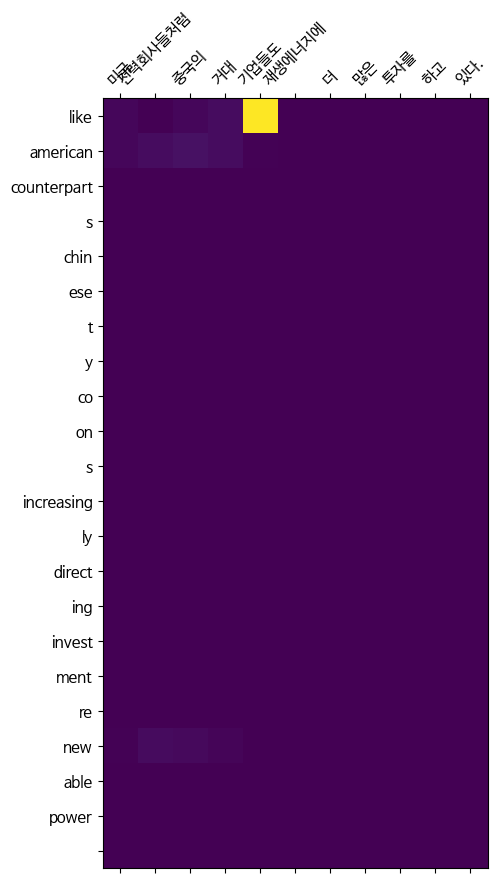

Input: 깁슨은 “파일럿은 그가 연습 때 배웠던 것처럼 판단을 내렸다”며 “그는 가장 안전한 방법인 여객기를 아들레이드로 회항하는 방법을 선택했다”고 전했다.
Predicted translation: ['new', 'york', 'times', 'reject', 'new', 'york', 'times', 'reject', 'ed', 'new', 'york', 'times', 'new', 'york', 'times', 'new', 'york', 'times', 'new', 'york', 'times', 'reject', 'ed', 'new', 'york', 'times', 'new', 'york', 'times', 'new']
(30, 30)


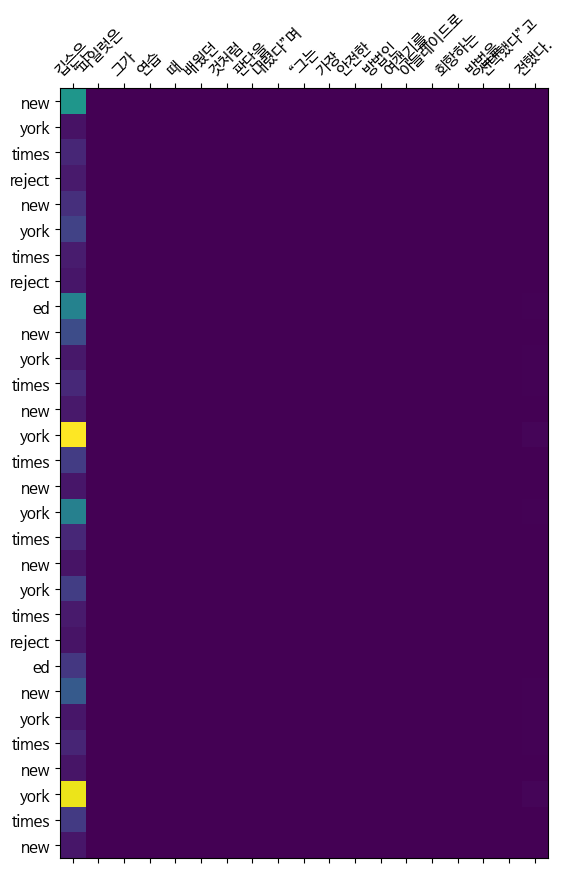

Input: 밀러는 의사가 그의 상태를 보고 29일에 퇴원시킬 것으로 예상했다.
Predicted translation: ['doctor', 's', 'monitor', 'ing', 'over', 'n', 'ight', 'like', 'ly', 'release', 'tuesday', 'miller', 'said', '']
(14, 30)


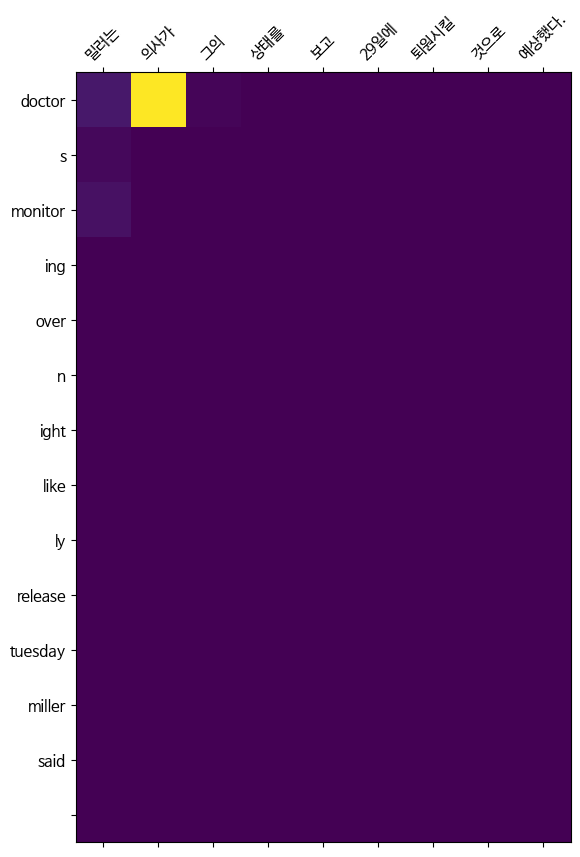

Input: 27일 방송된 ABC 방송의 ‘디스위크(This Week)’에서 진행자인 조지 스테파노풀로스는 매케인에게 애리조나주에서 차별 철폐 조치를 폐지하는 방안에 대해 일반투표를 실시하는 것을 지지하는지 질문했다.
Predicted translation: ['feder', 'al', 'reserve', 'morning', 'made', 'emergency', 'hal', 'f', 'th', 'stra', 'ddle', 'border', 'formal', 'i', 'ties', 'long', 'term', 'solution', 'ing', 'interview', 's', 'ke', 'y', 'scienti', 'st', 'developments', 'vocal', 'iz', 'ation', 'animal']
(30, 30)


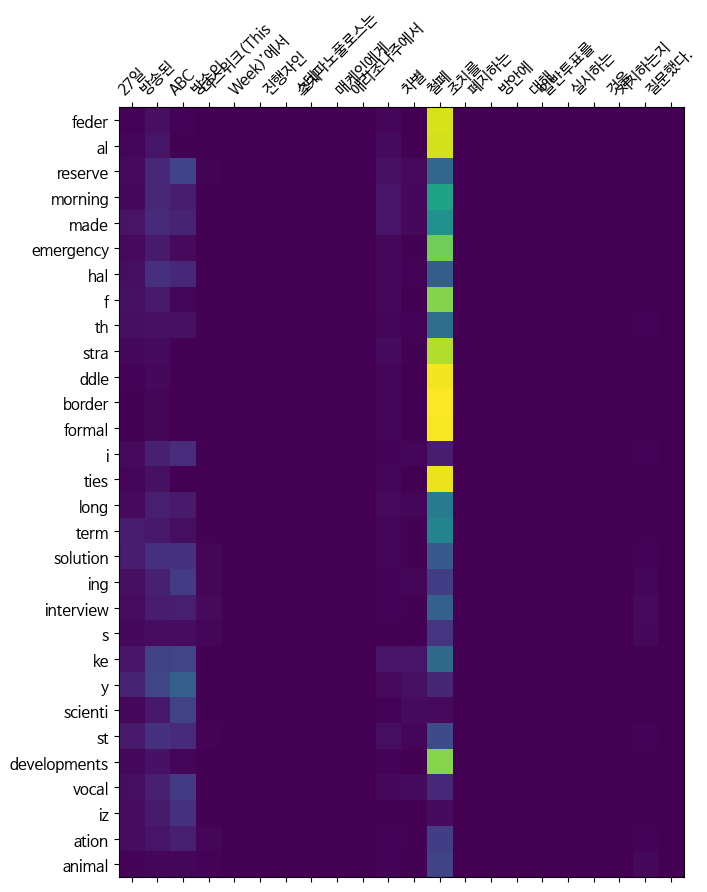

Input: 이번 합의안은 EU가 이달 초 만들었던 유사한 제안을 개선한 내용이었다.
Predicted translation: ['improve', 's', 'slight', 'ly', 'si', 'mila', 'r', 'proposal', 'eu', 'made', 'earlie', 'r', 'month', '']
(14, 30)


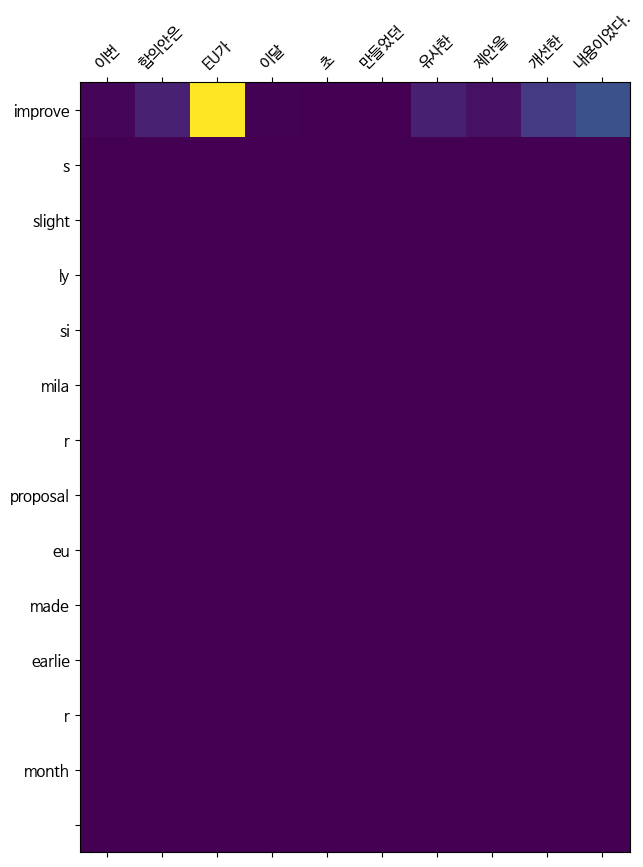

In [67]:
for sententence in train_example_sentence:
    translate(sententence, loaded_model, enc_tokenizer, dec_tokenizer, max_len=30)

&rarr; 그래도 비슷한 의미의 단어를 출력하는 것을 볼 수 있음(doctor)  
&rarr; 불용어 제거 시 그래도 너무 잘게 쪼개지는 문제가 어느 정도 보완됨(Ex_05_seq2seq_v0.9.ipynb 참고)  
&rarr; 중간에 "new", "york", "times" 같은 단어들이 반복되는 현상으로 볼 때 overfitting이 발생한 것으로 보임

In [68]:
emb_dim = 64
# h_dim = 512
h_dim = 128

encoder = Encoder(enc_vocab_size, emb_dim, h_dim).to(DEVICE)
attention = BahdanauAttn(h_dim).to(DEVICE)
decoder = Decoder(dec_vocab_size, emb_dim, h_dim, attention).to(DEVICE)
model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr = 1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

EPOCHS = 20
history = {'train_loss':[]}

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    # val_loss = val_step(model, train_loader, optimizer, criterion, epoch)
    history['train_loss'].append(train_loss)

    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1: 100%|██████████| 63/63 [00:07<00:00,  8.88it/s, loss=6.67]


Epoch 1/20, Train Loss: 7.1412


Epoch 2: 100%|██████████| 63/63 [00:06<00:00,  9.52it/s, loss=6.64]


Epoch 2/20, Train Loss: 6.6955


...

Epoch 18/20, Train Loss: 2.3102


Epoch 19: 100%|██████████| 63/63 [00:07<00:00,  8.95it/s, loss=1.8] 


Epoch 19/20, Train Loss: 2.1127


Epoch 20: 100%|██████████| 63/63 [00:06<00:00,  9.07it/s, loss=2]   

Epoch 20/20, Train Loss: 1.9397


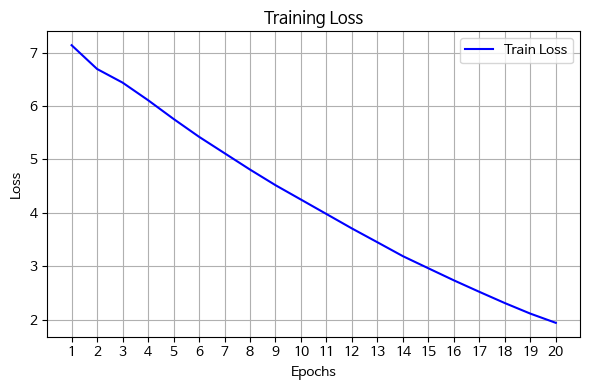

In [69]:
plot_history(history)

In [70]:
min_loss = min(history['train_loss'])
min_loss_epoch = history['train_loss'].index(min_loss) + 1

print(min_loss)
print(min_loss_epoch)

model_name = os.path.join(os.getcwd(), f'models/new_model-epoch-{min_loss_epoch}-loss-{min_loss:.4f}-emb-{emb_dim}-h_dim-{h_dim}.pt')
print(model_name)

1.9397284511535886
20
/home/minkyujeong/work/DeepDive/ch5_seq2seq/models/new_model-epoch-20-loss-1.9397-emb-64-h_dim-128.pt


In [71]:
# 모델 저장
torch.save(model.state_dict(), model_name)

In [72]:
loaded_model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)
checkpoint = torch.load(model_name, map_location=DEVICE)
loaded_model.load_state_dict(checkpoint)
loaded_model.eval() # 평가 모드로 변경
print("evaluation mode")

evaluation mode


Input: 시민들은 도시 속에 산다.
Predicted translation: ['tokuda', 'por', 'n', 'star', 's', 'operation', '']
(7, 30)


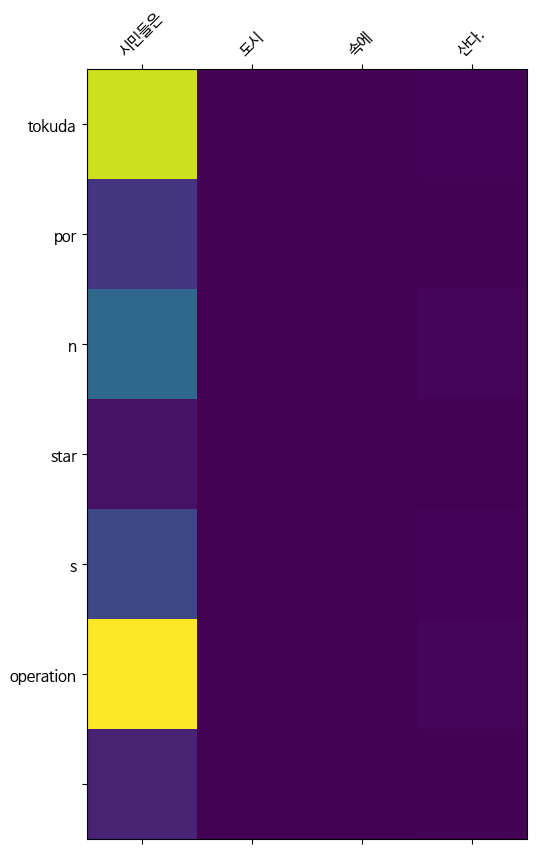

Input: 커피는 필요 없다.
Predicted translation: ['tokuda', 'por', 'n', '']
(4, 30)


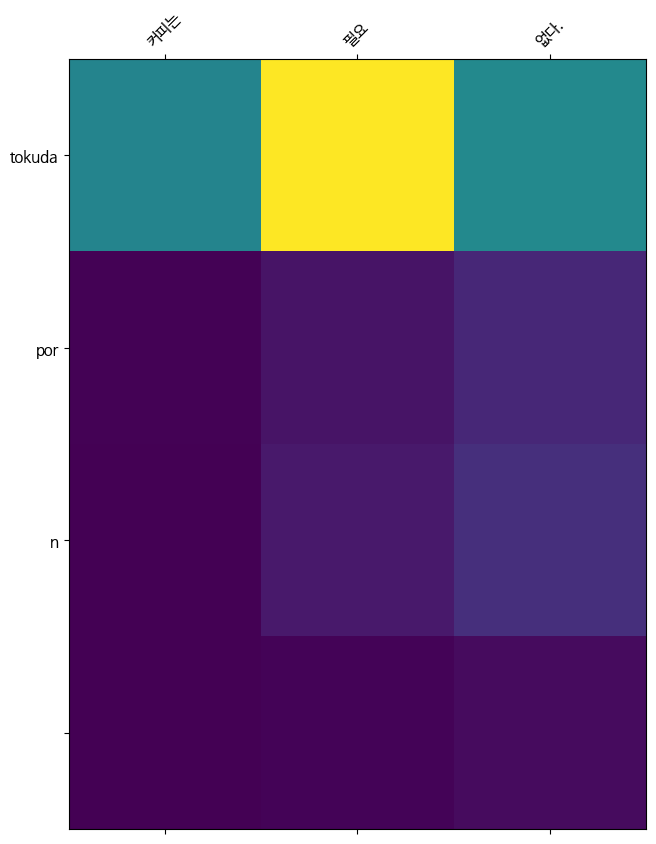

Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ['since', 'deb', 'ut', 'austria', 'trees', 's', 't', 'ook', 'digit', 'al', 'camera', 's', 'thre', 'e', 'designate', 'd', 'booth', 's', '']
(19, 30)


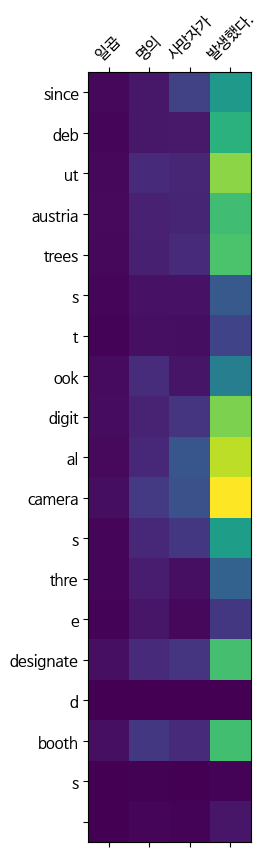

In [73]:
for sententence in example_sentence:
    translate(sententence, loaded_model, enc_tokenizer, dec_tokenizer, max_len=30)

Input: 미국 전력회사들처럼 중국의 거대 기업들도 재생에너지에 더 많은 투자를 하고 있다.
Predicted translation: ['', 'two', 'pull', 'ed', '', 'abilit', 'y', 'state', 'condole', 'e', 'zza', '', 'two', 'hours', 'ly', '', 'nine', 'constitution', 'increase', 'ing', 'day', '']
(22, 30)


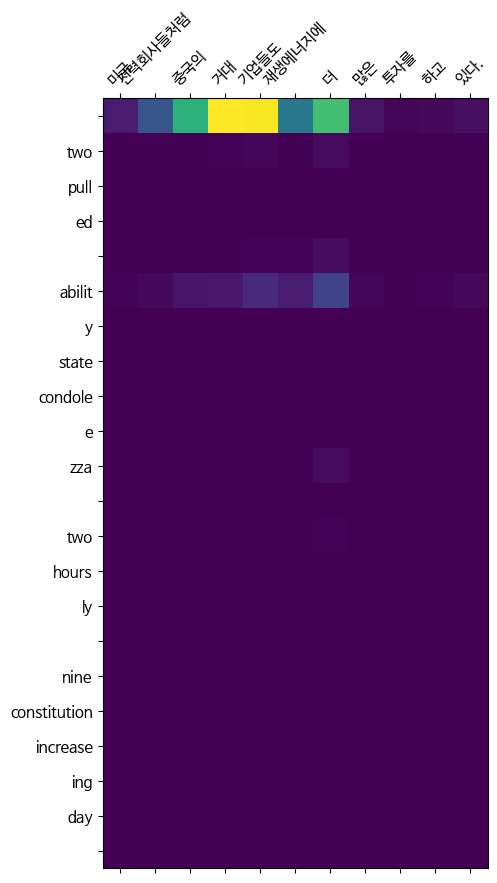

Input: 깁슨은 “파일럿은 그가 연습 때 배웠던 것처럼 판단을 내렸다”며 “그는 가장 안전한 방법인 여객기를 아들레이드로 회항하는 방법을 선택했다”고 전했다.
Predicted translation: ['real', 'madrid', 'w', 'ould', 'identif', 'ied', 'p', '']
(8, 30)


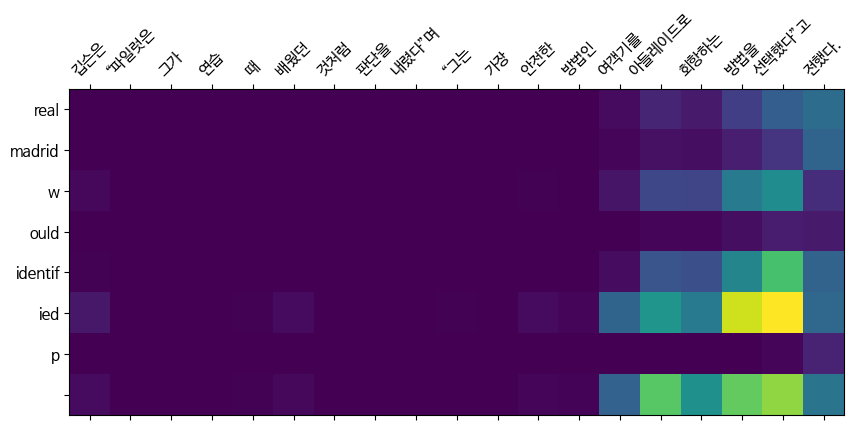

Input: 밀러는 의사가 그의 상태를 보고 29일에 퇴원시킬 것으로 예상했다.
Predicted translation: ['honest', 'ly', 'hope', 's', 'naples', 'rest', 'region', 'al', 's', 'city', 'inst', 'ill', 'sense', 'security', 'force', 's', 'personal', 'experiences', '']
(19, 30)


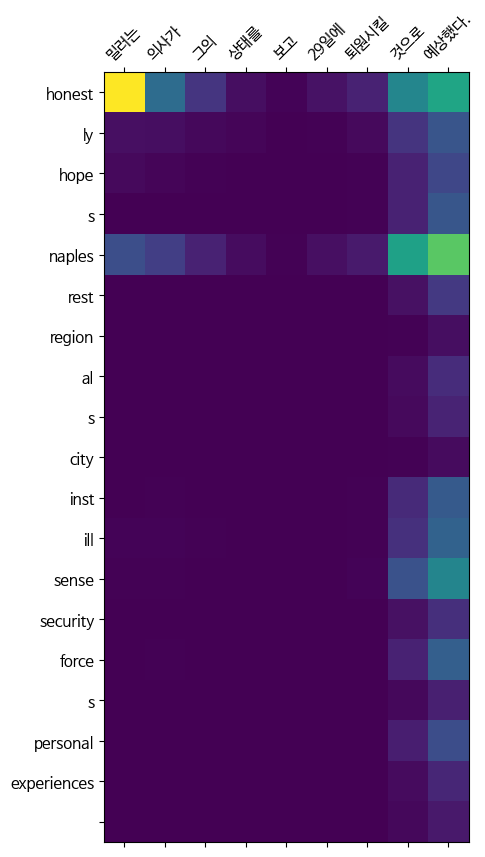

Input: 27일 방송된 ABC 방송의 ‘디스위크(This Week)’에서 진행자인 조지 스테파노풀로스는 매케인에게 애리조나주에서 차별 철폐 조치를 폐지하는 방안에 대해 일반투표를 실시하는 것을 지지하는지 질문했다.
Predicted translation: ['bal', 'e', 'denie', 'd', 'allegation', '', 'rich', 'list', 'personal', 'fortune', 'billion', 'yu', 'ity', 'late', 'sunday', '']
(16, 30)


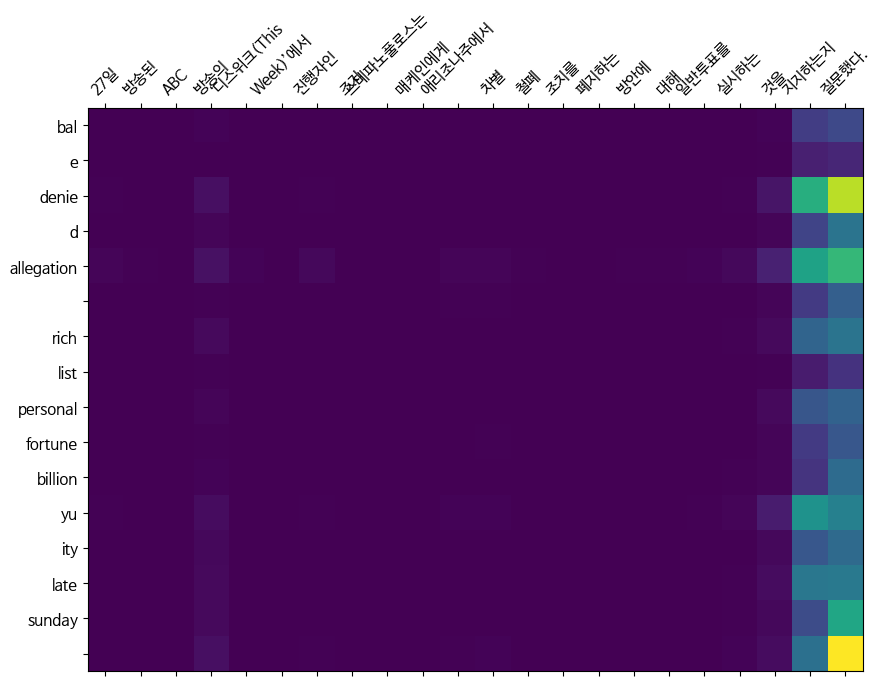

Input: 이번 합의안은 EU가 이달 초 만들었던 유사한 제안을 개선한 내용이었다.
Predicted translation: ['south', 'korea', 'propose', 'ly', 'contract', 'team', 's', 'know', 'n', 'ing', 'banana', 's', 'north', 'korean', 'foreign', 'minister', 'ya', 'dav', 'physic', 'ian', '', 'vice', 'presiden', 'cy', 'council', '']
(26, 30)


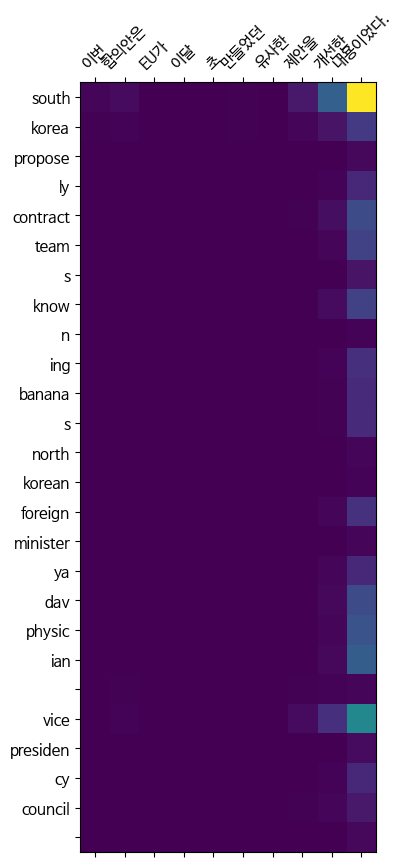

In [74]:
for sententence in train_example_sentence:
    translate(sententence, loaded_model, enc_tokenizer, dec_tokenizer, max_len=30)

- 파라미터 수를 줄여보려고 emb_dim, h_dim을 줄였는데, 오히려 더 엉뚱한 단어를 예측해서 도움이 되지 않는 것을 확인함

# 회고

- 코드 분석에 좀더 초점을 두고 진행을 하였다. 노드 코드와 달리 RNN 아키텍처에 데이터를 입력할 때, batch_first=True을 적용했기 때문에 연산 과정에서의 shape을 다 맞춰줘야 했다. 각 요소들을 일일이 출력해서 확인하면서 진행해서 시간이 오래 소요됐다. 그래도 어떤 과정을 거쳐서 연산이 이루어지는지 보다 구체적으로 확인할 수 있었다.
- train, validation dataset을 나누기도 어려울 정도로 데이터가 적다보니 성능이 썩 잘 나오지 않아서 augmentation을 수행하거나, 추가적인 개선안을 찾아야겠다.
- 불용어 처리를 하고 안 하고의 차이가 생각보다 큰 것을 확인할 수 있었다. (모델링보다 데이터 전처리가 더 효과가 클 수 있음을 체감함)